<a href="https://colab.research.google.com/github/mishraaashkacs242511-maker/Aashka/blob/main/T095_Aashka_Mishra_AI_Prac_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal RBFS Path: Ginger Andheri MIDC -> Kanhore Marg -> Mahakali Caves Rd -> Andheri-Ghatkopar Link Rd -> BD Sawant Marg -> Professor NS Phadke Rd -> GK Gokhale Bridge -> Barfiwala Flyover -> Juhu Ln -> Bhaktivedanta Swami Rd -> Cross Rd Number 4 -> NS Rd Number 5 -> Vaikunthlal Mehta Rd -> Juhu Tara Rd -> Juhu Beach
Total Road Distance: 8.38 km



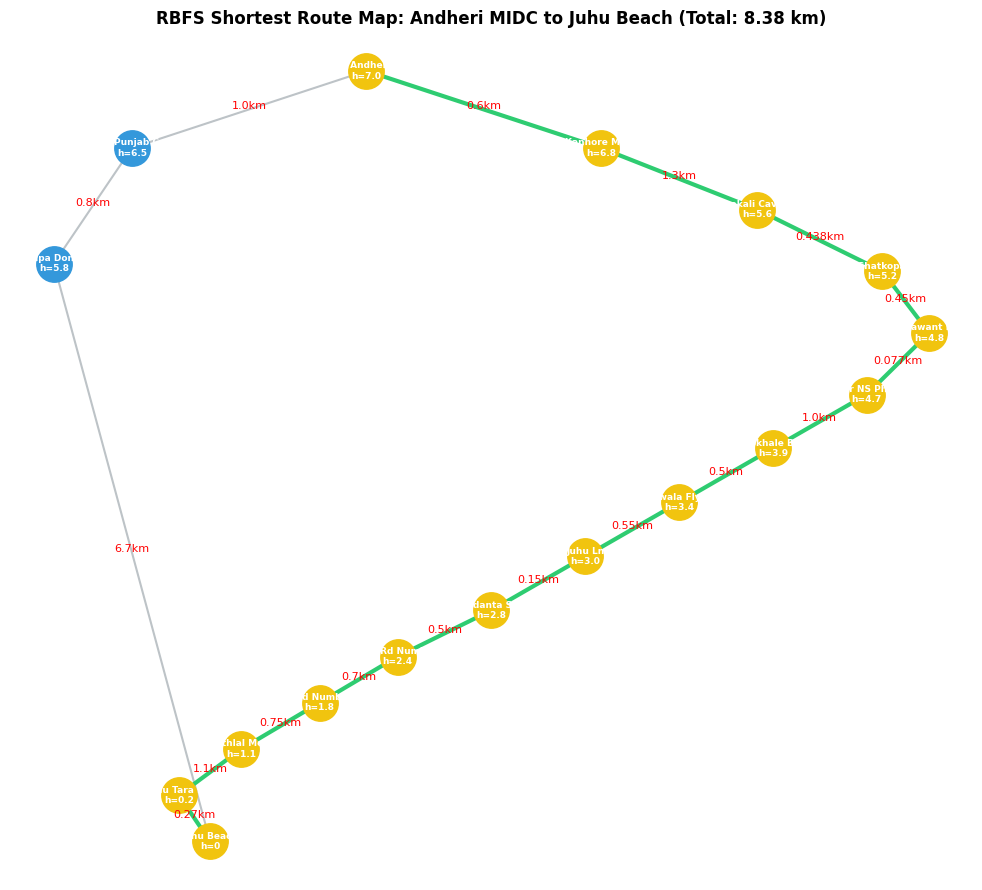

In [1]:
import matplotlib.pyplot as plt

graph = {
    'Ginger Andheri MIDC':        {'Sher E Punjab Colony': 1.0, 'Kanhore Marg': 0.6},
    'Sher E Punjab Colony':       {'Malpa Dongri': 0.8},
    'Malpa Dongri':               {'Juhu Beach': 6.7},
    'Kanhore Marg':               {'Mahakali Caves Rd': 1.3},
    'Mahakali Caves Rd':          {'Andheri-Ghatkopar Link Rd': 0.438},
    'Andheri-Ghatkopar Link Rd':  {'BD Sawant Marg': 0.45},
    'BD Sawant Marg':             {'Professor NS Phadke Rd': 0.077},
    'Professor NS Phadke Rd':     {'GK Gokhale Bridge': 1.0},
    'GK Gokhale Bridge':          {'Barfiwala Flyover': 0.5},
    'Barfiwala Flyover':          {'Juhu Ln': 0.55},
    'Juhu Ln':                    {'Bhaktivedanta Swami Rd': 0.15},
    'Bhaktivedanta Swami Rd':     {'Cross Rd Number 4': 0.5},
    'Cross Rd Number 4':          {'NS Rd Number 5': 0.7},
    'NS Rd Number 5':             {'Vaikunthlal Mehta Rd': 0.75},
    'Vaikunthlal Mehta Rd':       {'Juhu Tara Rd': 1.1},
    'Juhu Tara Rd':               {'Juhu Beach': 0.27},
    'Juhu Beach':                 {}
}

#h(n) to Juhu Beach (in km)
heuristics = {
    'Ginger Andheri MIDC': 7.0,
    'Sher E Punjab Colony': 6.5,
    'Malpa Dongri': 5.8,
    'Kanhore Marg': 6.8,
    'Mahakali Caves Rd': 5.6,
    'Andheri-Ghatkopar Link Rd': 5.2,
    'BD Sawant Marg': 4.8,
    'Professor NS Phadke Rd': 4.7,
    'GK Gokhale Bridge': 3.9,
    'Barfiwala Flyover': 3.4,
    'Juhu Ln': 3.0,
    'Bhaktivedanta Swami Rd': 2.8,
    'Cross Rd Number 4': 2.4,
    'NS Rd Number 5': 1.8,
    'Vaikunthlal Mehta Rd': 1.1,
    'Juhu Tara Rd': 0.2,
    'Juhu Beach': 0
}

coords = {
    'Ginger Andheri MIDC':       (2, 10),
    'Sher E Punjab Colony':      (0.5, 9),
    'Malpa Dongri':               (0, 7.5),
    'Kanhore Marg':               (3.5, 9),
    'Mahakali Caves Rd':          (4.5, 8.2),
    'Andheri-Ghatkopar Link Rd':  (5.3, 7.4),
    'BD Sawant Marg':             (5.6, 6.6),
    'Professor NS Phadke Rd':     (5.2, 5.8),
    'GK Gokhale Bridge':          (4.6, 5.1),
    'Barfiwala Flyover':          (4.0, 4.4),
    'Juhu Ln':                    (3.4, 3.7),
    'Bhaktivedanta Swami Rd':     (2.8, 3.0),
    'Cross Rd Number 4':          (2.2, 2.4),
    'NS Rd Number 5':             (1.7, 1.8),
    'Vaikunthlal Mehta Rd':       (1.2, 1.2),
    'Juhu Tara Rd':               (0.8, 0.6),
    'Juhu Beach':                 (1, 0)
}

def rbfs_search(start, goal):

    success, path, cost, _ = rbfs(start, goal, g=0, f_limit=float('inf'), path=[start])
    return path, cost

def rbfs(node, goal, g, f_limit, path):
    if node == goal:
        return True, path, g, g

    neighbors = graph[node]
    if not neighbors:
        return False, [], 0, float('inf')

    successors = []
    for neighbor, distance in neighbors.items():
        if neighbor not in path:
            next_g = g + distance
            next_f = max(next_g + heuristics[neighbor], g + heuristics[node])
            successors.append([next_f, neighbor, next_g])

    if not successors:
        return False, [], 0, float('inf')

    while True:
        successors.sort(key=lambda x: x[0])
        best = successors[0]

        if best[0] > f_limit:
            return False, [], 0, best[0]

        alternative_f = successors[1][0] if len(successors) > 1 else float('inf')

        success, result_path, total_g, returned_f = rbfs(
            best[1], goal, best[2], min(f_limit, alternative_f), path + [best[1]]
        )

        best[0] = returned_f

        if success:
            return True, result_path, total_g, returned_f


path, total_dist = rbfs_search('Ginger Andheri MIDC', 'Juhu Beach')
print(f"Optimal RBFS Path: {' -> '.join(path)}")
print(f"Total Road Distance: {round(total_dist, 2)} km\n")


plt.figure(figsize=(10, 9))

for node, neighbors in graph.items():
    x1, y1 = coords[node]
    for neighbor, dist in neighbors.items():
        x2, y2 = coords[neighbor]
        is_path = node in path and neighbor in path and path.index(neighbor) == path.index(node) + 1
        color, width = ('#2ecc71', 3) if is_path else ('#bdc3c7', 1.5)

        plt.plot([x1, x2], [y1, y2], color=color, linewidth=width, zorder=1)
        plt.text((x1 + x2) / 2, (y1 + y2) / 2, f"{dist}km", color='red', fontsize=8, ha='center')

for node, (x, y) in coords.items():
    color = '#f1c40f' if node in path else '#3498db'
    plt.scatter(x, y, color=color, s=650, zorder=2)
    plt.text(x, y, f"{node}\nh={heuristics[node]}", ha='center', va='center', color='white', fontsize=6.5, fontweight='bold')

plt.title(f"RBFS Shortest Route Map: Andheri MIDC to Juhu Beach (Total: {round(total_dist, 2)} km)", fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('RBFS_Andheri_to_JuhuBeach.png', dpi=150)
plt.show()